# Machine Learning II - Project 4
## Composing a Bach Chorale 
- In this project, taken from Geron, you will use CNNs and RNNs to create a Bach chorale
- It is composed of 382 chorales composed by Johann Sebastian Bach
- Each chorale is 100 to 640 time steps long, and each time step contains four integers
- Each of these integers corresponds to a note’s index on a piano, with zero indicating that no note is played
- Train a model consisting of both RNN and CNN layers that can predict the next time step (four notes), given a sequence of time steps from a chorale
- It does not matter to me if you choose to utilize the basic (vanilla) RNN, an LSTM, or a GRU
- Use your model to generate “Bach-like” music, one note at a time
- This can be accomplished by giving the model the start of a chorale and letting it compose, i.e., predict, the next time step
- Then, append this result to the input sequence and have the model compose the subsequent note, and so on.

# Preprocessing

In [1]:
from pathlib import Path
import tarfile
import urllib.request
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import torch.nn.functional as F
from torch.utils.data import DataLoader
import random

from torch.utils.data.sampler import SubsetRandomSampler

In [2]:
data_directory = "jsb_chorales"
file_path = Path(data_directory) / 'train' / 'chorale_000.csv'
print(file_path.read_text()[:84])

note0,note1,note2,note3
74,70,65,58
74,70,65,58
74,70,65,58
74,70,65,58
75,70,58,55



In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(1901)
np.random.seed(1901)
print(f"Using device: {device}")

Using device: cuda


In [4]:
import csv

def load_chorales(data_directory):
    chorales = {"train": [], "valid": [], "test": []}
    for subset, chorale_list in chorales.items():
        for chorale_path in sorted((data_directory / subset).glob("*.csv")):
            with chorale_path.open() as f:
                reader = csv.reader(f)
                next(reader)  # skip header row
                chorale = [[int(note) for note in row] for row in reader]
                chorale_list.append(torch.tensor(chorale))
    return chorales

chorales = load_chorales(Path(data_directory))

In [ ]:
chorales["train"][0][:5]

In [5]:
def preprocess_note_indices(note_indices, length=None):
    notes_one_hot = F.one_hot(note_indices, num_classes=48).to(torch.float32)
    if length is None:
        length = len(note_indices)
    idx = torch.arange(len(note_indices), dtype=torch.float32,
                       device=note_indices.device).view(-1, 1) - 1
    return torch.cat([
        notes_one_hot,
        idx % 4,
        idx % 16 // 4,
        idx / (length - 1)
    ], dim=-1)

class BachDataset(torch.utils.data.Dataset):
    def __init__(self, chorales, window_length):
        self.chorales = chorales
        self.windows = []
        sos = torch.tensor([1])
        for chorale in chorales:
            notes = chorale.view(-1)
            note_indices = torch.cat([sos, F.relu(notes - 34)])
            X = preprocess_note_indices(note_indices)
            for index in range(len(notes) - window_length):
                self.windows.append((
                    X[index : index + window_length],
                    note_indices[index + 1 : index + window_length + 1]
                ))

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, index):
        return self.windows[index]

window_length = 128
train_set = BachDataset(chorales["train"], window_length)
valid_set = BachDataset(chorales["valid"], window_length)
test_set = BachDataset(chorales["test"], window_length)

In [6]:
torch.manual_seed(42)
batch_size = 32
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size)
test_loader = DataLoader(test_set, batch_size=batch_size)

data_loaders = {'train' : train_loader, 'valid': valid_loader, 'test' : test_loader}

# Hyperparameter Tuning

In [ ]:
import torch.optim as optim
import optuna
from optuna.integration import PyTorchLightningPruningCallback

In [ ]:
def objective(trial, n_workers=2, n_classes=48, data_loaders=data_loaders):
    learning_rate = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    drop = trial.suggest_float("dropout", 0.1, 0.5, log=True)

    model = ModelFour(dropout_r=drop)
    
    train_loader = data_loaders["train"]
    valid_dataloader = data_loaders["valid"]
    if torch.cuda.is_available():
        model.cuda()

    
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate
    )
    loss = nn.CrossEntropyLoss()
    print("Optimizer and loss set")
    for epoch in range(5):
        model.train()
        print("We're in...")
        for batch_idx, (data, target) in tqdm(enumerate(train_loader)):
            if torch.cuda.is_available():
                data, target = data.cuda(), target.cuda()
            optimizer.zero_grad()
            output = model(data)
            train_loss = loss(output, target)
            train_loss.backward()
            optimizer.step()
        print(f"Training {batch_idx} Done")

        val_loss = 0.0

        with torch.no_grad():
            model.eval()

            for batch_idx, (data, target) in tqdm(
                enumerate(valid_dataloader)):
                # move data to GPU if available
                if torch.cuda.is_available():
                    data, target = data.cuda(), target.cuda()
    
                output = model(data)
                val_loss += loss(output, target).item()
            val_loss /= len(valid_dataloader)
            print(f"Validating {batch_idx} Done")
    del model
    torch.cuda.empty_cache()

    return val_loss

In [ ]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15)
print("Best Hyperparameters:", study.best_params)

# Models

In [7]:
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1, **kwargs):
        super().__init__()
        self.pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, padding=self.pad, dilation=dilation, **kwargs)

    def forward(self, x):
        out = self.conv(x)
        return out[:, :, :-self.pad] if self.pad > 0 else out

## Model 1

In [ ]:
class ModelOne(nn.Module):
    def __init__(self, input_size, hidden_size, vocab_size):
        super().__init__()
        self.conv = CausalConv1d(input_size, hidden_size, kernel_size=2)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.linear = nn.Linear(hidden_size, vocab_size)
    def forward(self, X):
        Z = X.permute(0, 2, 1)
        Z = self.conv(Z)
        Z = Z.permute(0, 2, 1)
        Z = torch.relu(Z)
        Z, _states = self.gru(Z)
        Z = self.linear(Z)
        return Z.permute(0, 2, 1)

torch.manual_seed(42)
model = ModelOne(input_size=51, hidden_size=32, vocab_size=48)
model = model.to(device)

In [ ]:
dummy = torch.randn(32, 128, 51).to(device)
print(model_one(dummy).shape)  # should be [32, 48, 128]

## Model 2

In [ ]:
class ModelTwo(nn.Module):
    def __init__(self, n_inputs=51, conv_dim=32, lstm_dim=64, vocab_size=48):
        super().__init__()
        self.conv = CausalConv1d(n_inputs, conv_dim, kernel_size=2, dilation=2**1)
        self.relu = nn.ReLU()
        self.batchnorm = nn.BatchNorm1d(conv_dim)
        self.lstm = nn.LSTM(input_size=conv_dim, hidden_size=lstm_dim, batch_first=True)
        self.output = nn.Linear(lstm_dim, vocab_size)

    def forward(self, X):
        Z = X.transpose(1, 2)    
        Z = self.conv(Z)          
        Z = self.relu(Z)          
        Z = self.batchnorm(Z)     
        Z = Z.transpose(1, 2)   
        Z, _ = self.lstm(Z)
        Z = self.output(Z)
        return Z.transpose(1, 2)

torch.manual_seed(42)
model = ModelTwo().to(device)

## Model 3

In [ ]:
class ModelThree(nn.Module):
    def __init__(self, n_inputs=51, conv_dim=32, lstm_dim=64, vocab_size=48):
        super().__init__()
        self.conv1 = CausalConv1d(n_inputs, conv_dim, kernel_size=2, dilation=2**1)
        self.relu1 = nn.ReLU()
        self.batchnorm1 = nn.BatchNorm1d(conv_dim)
        
        self.conv2 = CausalConv1d(conv_dim, conv_dim, kernel_size=2, dilation=2**2)
        self.relu2 = nn.ReLU()
        self.batchnorm2 = nn.BatchNorm1d(conv_dim)
        
        self.lstm = nn.LSTM(input_size=conv_dim, hidden_size=lstm_dim, batch_first=True)
        self.output = nn.Linear(lstm_dim, vocab_size)

    def forward(self, X):
        Z = X.transpose(1, 2)          
        Z = self.relu1(self.batchnorm1(self.conv1(Z)))
        Z = self.relu2(self.batchnorm2(self.conv2(Z)))
        Z = Z.transpose(1, 2)        
        Z, _ = self.lstm(Z)
        Z = self.output(Z)
        return Z.transpose(1, 2)

torch.manual_seed(42)
model = ModelThree().to(device)

In [ ]:
dummy = torch.randn(32, 128, 51).to(device)
print(model(dummy).shape)  # should be [32, 48, 128]

## Model 4

In [8]:
class ModelFour(nn.Module):
    def __init__(self, dropout_r=0.25, n_inputs=51, conv_dim=32, lstm_dim=64, vocab_size=48):
        super().__init__()
        self.conv1 = CausalConv1d(n_inputs, conv_dim, kernel_size=2, dilation=2**1)
        self.batchnorm1 = nn.BatchNorm1d(conv_dim)
        self.relu1 = nn.ReLU()
        self.dropout = nn.Dropout1d(p=dropout_r)
        
        self.conv2 = CausalConv1d(conv_dim, conv_dim, kernel_size=2, dilation=2**2)
        self.batchnorm2 = nn.BatchNorm1d(conv_dim)
        self.relu2 = nn.ReLU()
        
        self.lstm = nn.LSTM(input_size=conv_dim, hidden_size=lstm_dim, batch_first=True)
        self.output = nn.Linear(lstm_dim, vocab_size)

    def forward(self, X):
        Z = X.transpose(1, 2)          
        Z = self.dropout(self.batchnorm1(self.relu1(self.conv1(Z))))
        Z = self.batchnorm2(self.relu2(self.conv2(Z)))
        Z = Z.transpose(1, 2)        
        Z, _ = self.lstm(Z)
        Z = self.output(Z)
        return Z.transpose(1, 2)

torch.manual_seed(42)
model = ModelFour(dropout_r=0.18894165403743604).to(device)

## Model 3
*Try to change this up a bit to not use CausalConv1d*

In [ ]:


class BachModel(nn.Module):
    def __init__(self, n_inputs=51, conv_dim=32, lstm_dim=64, n_notes=48):
        super().__init__()
        conv_layers = []
        for idx in range(4):
            conv_layers += [
                CausalConv1d(n_inputs, conv_dim, kernel_size=2, dilation=2**idx),
                nn.ReLU(),
                nn.BatchNorm1d(conv_dim),
            ]
            n_inputs = conv_dim

        self.conv_stack = nn.Sequential(*conv_layers)
        self.lstm = nn.LSTM(input_size=conv_dim, hidden_size=lstm_dim, batch_first=True)
        self.output = nn.Linear(lstm_dim, n_notes)

    def forward(self, X):
        Z = X.transpose(1, 2)
        Z = self.conv_stack(Z)
        Z = Z.transpose(1, 2)
        Z, _ = self.lstm(Z)
        Z = self.output(Z)
        return Z.transpose(1, 2)

torch.manual_seed(42)
model = BachModel().to(device)


# Functions for Evaluating Models

In [9]:
import torchmetrics

In [10]:
torch.manual_seed(42)
optimizer = torch.optim.Adam(model.parameters(), lr=0.00023969392522141887)
loss = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=10, factor=0.1)

In [11]:
def train_one_epoch(train_dataloader, model, optimizer, loss):
    """
    Performs one epoch of training
    """
    if torch.cuda.is_available():
        model.cuda()  # -
    model.train()
    train_loss = 0.0

    for batch_idx, (data, target) in tqdm(
        enumerate(train_dataloader),
        desc="Training",
        total=len(train_dataloader),
        leave=True,
        ncols=80,
    ):
        if torch.cuda.is_available():
            data, target = data.cuda(), target.cuda()
        optimizer.zero_grad()
        output = model(data)
        loss_value = loss(output, target)
        loss_value.backward() 
        optimizer.step()
        train_loss = train_loss + (
            (1 / (batch_idx + 1)) * (loss_value.data.item() - train_loss))

    return train_loss

In [12]:
def valid_one_epoch(valid_dataloader, model, loss):
    """
    Validate at the end of one epoch
    """

    with torch.no_grad():
        model.eval()
        if torch.cuda.is_available():
            model.cuda()
        valid_loss = 0.0
        for batch_idx, (data, target) in tqdm(
            enumerate(valid_dataloader),
            desc="Validating",
            total=len(valid_dataloader),
            leave=True,
            ncols=80,
        ):
            if torch.cuda.is_available():
                data, target = data.cuda(), target.cuda()
            output = model(data)
            loss_value = loss(output, target)
            valid_loss = valid_loss + (
                (1 / (batch_idx + 1)) * (loss_value.data.item() - valid_loss))

    return valid_loss

In [13]:
def optimize(data_loaders, model, optimizer, loss, n_epochs, save_path, patience, scheduler, interactive_tracking=False):
    if interactive_tracking:
        liveloss = PlotLosses()
    else:
        liveloss = None
    valid_loss_min = None
    logs = {}
    wait = 0

    for epoch in range(1, n_epochs + 1):

        train_loss = train_one_epoch(
            data_loaders["train"], model, optimizer, loss
        )

        valid_loss = valid_one_epoch(data_loaders["valid"], model, loss)
        print(f"Epoch: {epoch} \tTraining Loss: {train_loss:.6f} \tValidation Loss: {valid_loss:.6f}")
        if valid_loss_min is None or ((valid_loss_min - valid_loss) / valid_loss_min > 0.01):
            print(f"New minimum validation loss: {valid_loss:.6f}. Saving model ...")

            # Save the weights to save_path
            torch.save(model.state_dict(), save_path)  # -

            valid_loss_min = valid_loss
            wait = 0
        else:
            wait +=1
            if wait >= patience:
                print("Early stopping!")
                break
            
        scheduler.step(valid_loss)

        if interactive_tracking:
            logs["loss"] = train_loss
            logs["val_loss"] = valid_loss
            logs["lr"] = optimizer.param_groups[0]["lr"]
            liveloss.update(logs)
            liveloss.send()

In [14]:
from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot
from tqdm import tqdm

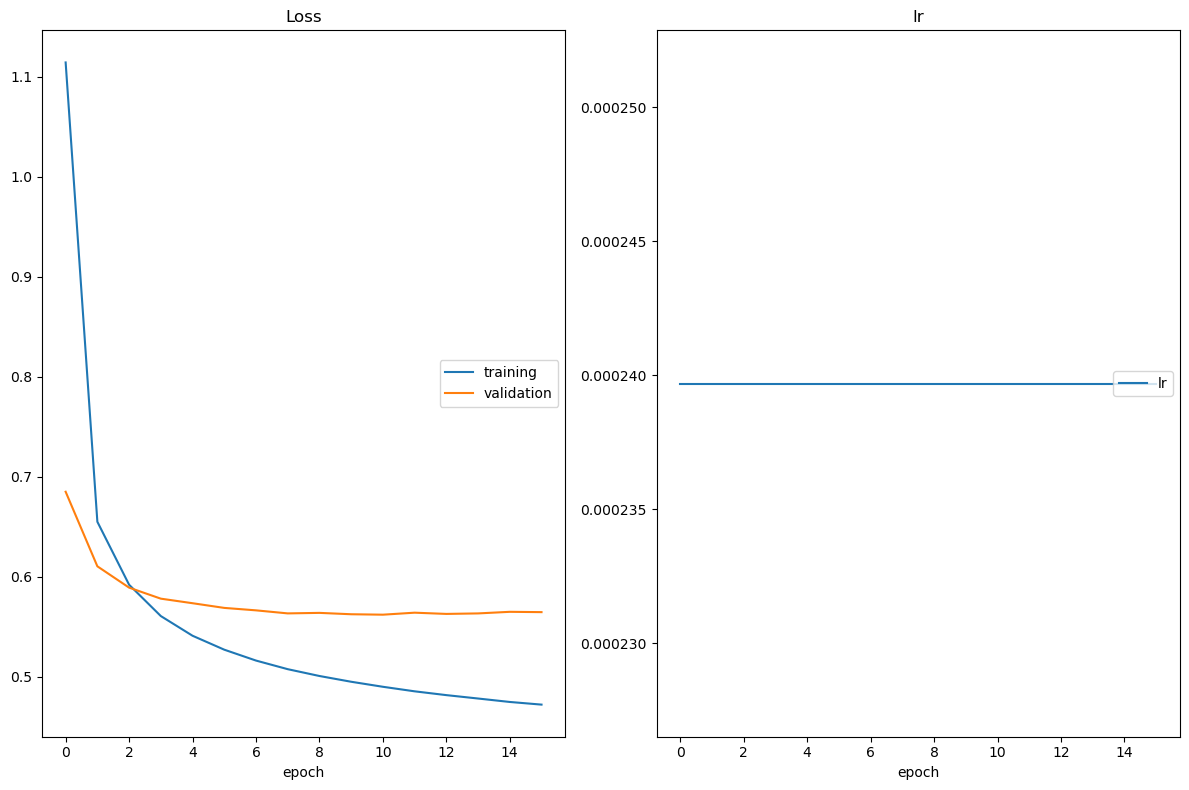

Loss
	training         	 (min:    0.472, max:    1.114, cur:    0.472)
	validation       	 (min:    0.562, max:    0.685, cur:    0.564)
lr
	lr               	 (min:    0.000, max:    0.000, cur:    0.000)


Validating: 100%|██████████████████████████| 1997/1997 [00:02<00:00, 954.55it/s]

Epoch: 17 	Training Loss: 0.469847 	Validation Loss: 0.566158
Early stopping!


In [15]:
n_epochs = 100

optimize(
    data_loaders,
    model,
    optimizer,
    loss,
    n_epochs,
    'model4.pt',
    7,
    scheduler,
    interactive_tracking=True
)

In [16]:
def one_epoch_test(test_dataloader, model, loss, metric):
    # monitor test loss and accuracy
    test_loss = 0.
    correct = 0.
    total = 0.

    # we do not need the gradients
    with torch.no_grad():

        # set the model to evaluation mode
        model.eval()  # -
        metric.reset()

        # if the GPU is available, move the model to the GPU
        if torch.cuda.is_available():
            model = model.cuda()

        # Loop over test dataset
        # We also accumulate predictions and targets so we can return them
        preds = []
        actuals = []

        for batch_idx, (data, target) in tqdm(
                enumerate(test_dataloader),
                desc='Testing',
                total=len(test_dataloader),
                leave=True,
                ncols=80
        ):
            # move data to GPU if available
            if torch.cuda.is_available():
                data, target = data.cuda(), target.cuda()

            # 1. forward pass: compute predicted outputs by passing inputs to the model
            logits = model(data)  # =
            metric.update(logits, target)

            # 2. calculate the loss
            loss_value = loss(logits, target).detach()  # =

            # 3. update average test loss
            test_loss = test_loss + ((1 / (batch_idx + 1)) * (loss_value.data.item() - test_loss))

            # 4. convert logits to predicted class
            # NOTE: the predicted class is the index of the max of the logits
            pred = logits.data.max(1, keepdim=True)[1]  # =

            # 5. compare predictions to true label

            preds.extend(pred.data.cpu().numpy().squeeze())
            actuals.extend(target.data.view_as(pred).cpu().numpy().squeeze())

    print('Test Loss: {:.6f}\n'.format(test_loss))

    percent = metric.compute() * 100

    print('Test Accuracy: {:.2f}%\n'.format(percent))
    
    return test_loss, preds, actuals

In [17]:
model.load_state_dict(torch.load('model4.pt'))

<All keys matched successfully>

In [18]:
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=48).to(device)

In [19]:
test_loss, preds, actuals = one_epoch_test(data_loaders['test'], model, loss, accuracy)

Testing: 100%|█████████████████████████████| 2055/2055 [00:02<00:00, 771.48it/s]

Test Loss: 0.583553

Test Accuracy: 82.76%

